In [24]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import yfinance as yf

# Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with your desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="2y")
data.reset_index(inplace=True)

In [25]:
### 2. Data Cleaning
# Selecting relevant columns
data = data[['Date', 'Close']]
data.dropna(inplace=True)

In [26]:
### 3. Feature Engineering
# Adding EMA20 and EMA50
data['EMA20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA50'] = data['Close'].ewm(span=50, adjust=False).mean()
data.dropna(inplace=True)  # Drop rows with NaN values after EMA calculation

In [27]:
### 4. Splitting Data into Training and Testing Sets
# Splitting the data
train_size = int(len(data) * 0.8)  # 80% training, 20% testing
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Saving to CSV for inspection
train_data.to_csv("Training_Data.csv", index=False)
test_data.to_csv("Testing_Data.csv", index=False)

In [28]:
### 5. Scaling and Preparing Data for Model
# Fit the scaler only on training data
sc_train = MinMaxScaler(feature_range=(0, 1))
train_scaled = sc_train.fit_transform(train_data[['Close', 'EMA20', 'EMA50']])
sc_test = MinMaxScaler(feature_range=(0, 1))
test_scaled = sc_test.fit_transform(test_data[['Close', 'EMA20', 'EMA50']])

# Debugging scaling
print("Scaled Train Min:", np.min(train_scaled, axis=0))
print("Scaled Train Max:", np.max(train_scaled, axis=0))
print("Scaled Test Min:", np.min(test_scaled, axis=0))
print("Scaled Test Max:", np.max(test_scaled, axis=0))

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i])
    y_train.append(train_scaled[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))

Scaled Train Min: [0. 0. 0.]
Scaled Train Max: [1. 1. 1.]
Scaled Test Min: [0. 0. 0.]
Scaled Test Max: [1. 1. 1.]


Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1475
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0143
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0123
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0073
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0089
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0093
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0096
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0059
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0065
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0074
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0071
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0051
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0057
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0069
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0054
E

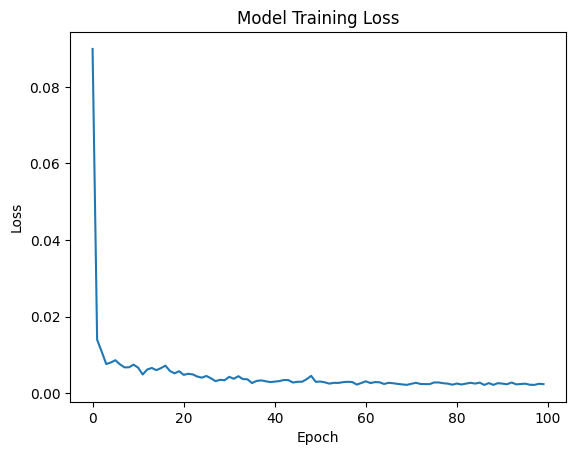

In [29]:
### 6. Building the LSTM Model
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

# Compiling and fitting the model
regressor.compile(optimizer='adam', loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=100, batch_size=32)

### Plotting Training Loss
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


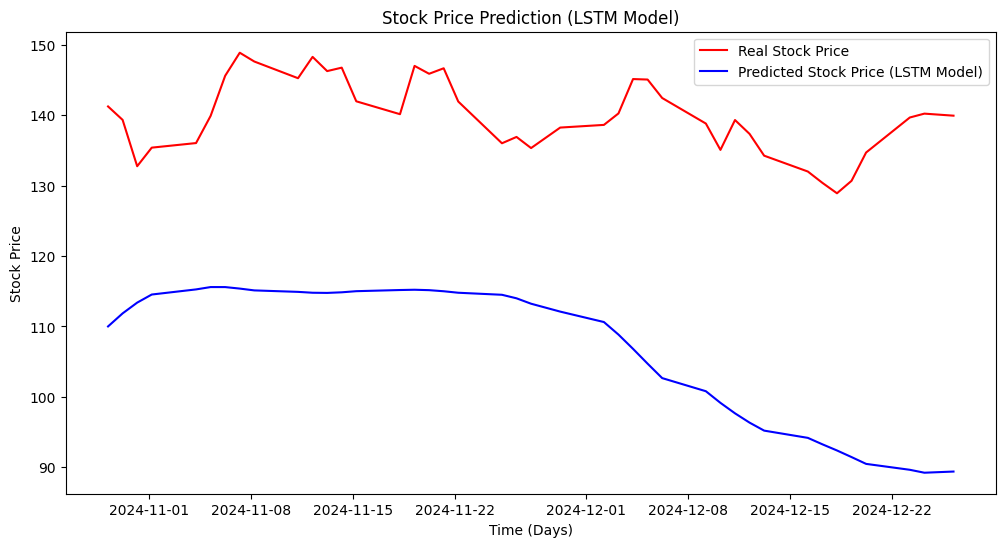

Trend Accuracy (LSTM Model): 52.50%
Mean Absolute Percentage Error (MAPE) (LSTM Model): 23.62%
Overall Accuracy Score (LSTM Model): 76.38%


In [30]:
### 7. Preparing Test Data and Making Predictions
# Preparing test data
X_test = []
y_test = test_data['Close'].values[60:]  # Actual 'Close' prices for comparison
for i in range(60, len(test_scaled)):
    X_test.append(test_scaled[i-60:i])
X_test = np.array(X_test, dtype=np.float32)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Predicting stock prices
predicted_stock_price = regressor.predict(X_test, batch_size=32)
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], 1))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc_train.inverse_transform(
    np.pad(predicted_stock_price_expanded, ((0, 0), (0, 2)), constant_values=0))[:, 0]

# Ensure all arrays have the same length
min_length = min(len(test_data['Date'].iloc[60:]), len(y_test), len(predicted_stock_price))
dates_aligned = test_data['Date'].iloc[60:].values[:min_length]
y_test_aligned = y_test[:min_length]
predicted_stock_price_aligned = predicted_stock_price[:min_length]

# Combine arrays and save fitted output
fitted_output = pd.DataFrame({
    'Date': dates_aligned,
    'Real Price': y_test_aligned,
    'Predicted Price': predicted_stock_price_aligned
})
fitted_output.to_csv("Fitted_Data_Output_LSTM_Model.csv", index=False)

# Plotting fitted data
plt.figure(figsize=(12, 6))
plt.plot(dates_aligned, y_test_aligned, color='red', label='Real Stock Price')
plt.plot(dates_aligned, predicted_stock_price_aligned, color='blue', label='Predicted Stock Price (LSTM Model)')
plt.title('Stock Price Prediction (LSTM Model)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

### Backtesting and Accuracy Assessment
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test_aligned))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price_aligned))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_aligned - predicted_stock_price_aligned) / y_test_aligned)) * 100

# Overall accuracy score
overall_accuracy = 100 - mape

# Print metrics
print("Trend Accuracy (LSTM Model): {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE) (LSTM Model): {:.2f}%".format(mape))
print("Overall Accuracy Score (LSTM Model): {:.2f}%".format(overall_accuracy))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


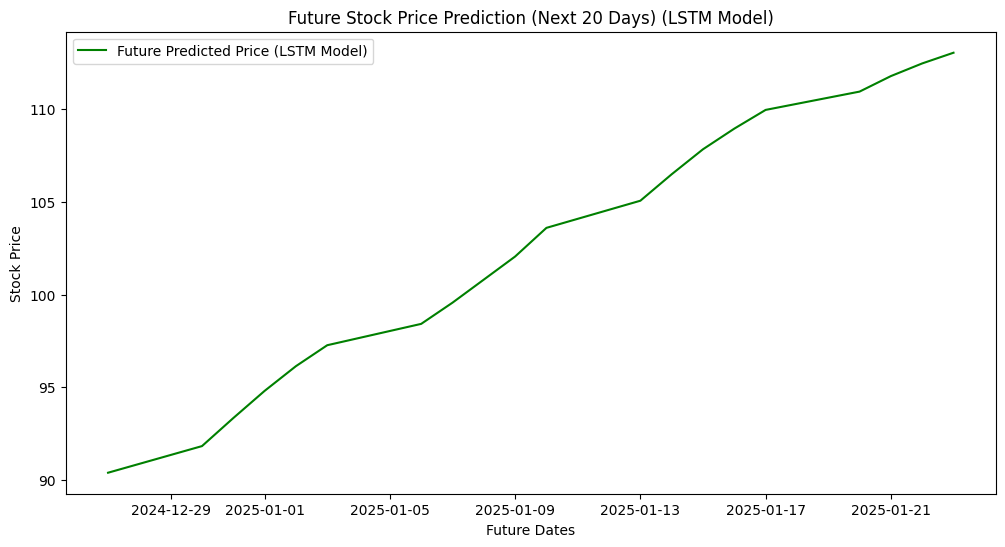

In [31]:
### 8. Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = test_scaled[-60:]
future_predictions = []

for _ in range(20):
    # Reshape input to match the expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = regressor.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, 3))  # Adjusted to match input features (Close, EMA20, EMA50)
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc_train.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, 2)), constant_values=0)
)[:, 0]

# Generate future dates for predictions
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]

# Save future predictions
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions_LSTM_Model.csv", index=False)

# Plotting future predictions
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price (LSTM Model)')
plt.title('Future Stock Price Prediction (Next 20 Days) (LSTM Model)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()